In [ ]:
!unzip ck+.zip -d ck

Archive:  ck+.zip
  inflating: ck/CK+48/anger/S010_004_00000017.png  
  inflating: ck/CK+48/anger/S010_004_00000018.png  
  inflating: ck/CK+48/anger/S010_004_00000019.png  
  inflating: ck/CK+48/anger/S011_004_00000019.png  
  inflating: ck/CK+48/anger/S011_004_00000020.png  
  inflating: ck/CK+48/anger/S011_004_00000021.png  
  inflating: ck/CK+48/anger/S014_003_00000028.png  
  inflating: ck/CK+48/anger/S014_003_00000029.png  
  inflating: ck/CK+48/anger/S014_003_00000030.png  
  inflating: ck/CK+48/anger/S022_005_00000030.png  
  inflating: ck/CK+48/anger/S022_005_00000031.png  
  inflating: ck/CK+48/anger/S022_005_00000032.png  
  inflating: ck/CK+48/anger/S026_003_00000013.png  
  inflating: ck/CK+48/anger/S026_003_00000014.png  
  inflating: ck/CK+48/anger/S026_003_00000015.png  
  inflating: ck/CK+48/anger/S028_001_00000022.png  
  inflating: ck/CK+48/anger/S028_001_00000023.png  
  inflating: ck/CK+48/anger/S028_001_00000024.png  
  inflating: ck/CK+48/anger/S029_001_00000017.

In [ ]:
!pip install scikit-image deap

import os
import cv2
import numpy as np
from tqdm import tqdm

from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
DATASET_PATH = "/content/ck/CK+48"  # change if needed

IMG_SIZE = 48

def load_data():
    X, y = [], []
    label_map = {}
    label_count = 0

    for emotion in os.listdir(DATASET_PATH):
        label_map[label_count] = emotion
        folder = os.path.join(DATASET_PATH, emotion)

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append(label_count)

        label_count += 1

    return np.array(X), np.array(y)

X, y = load_data()
print("Dataset:", X.shape)

Dataset: (981, 48, 48)


In [ ]:
# import joblib
# joblib.dump(label_map, "labels.pkl")

In [ ]:
def extract_features(images):
    features = []

    for img in tqdm(images):
        # HOG
        hog_feat = hog(img, pixels_per_cell=(8,8),
                       cells_per_block=(2,2),
                       feature_vector=True)

        # LBP
        lbp = local_binary_pattern(img, P=8, R=1)
        lbp_hist, _ = np.histogram(lbp.ravel(),
                                  bins=np.arange(0, 11),
                                  range=(0, 10))

        features.append(np.concatenate([hog_feat, lbp_hist]))

    return np.array(features)

X_feat = extract_features(X)
print("Feature shape:", X_feat.shape)

100%|██████████| 981/981 [00:01<00:00, 506.53it/s]

Feature shape: (981, 910)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

In [ ]:
NUM_FEATURES = X_scaled.shape[1]
POP_SIZE = 20
GENERATIONS = 5

# Initialize Q-bit population (probabilities)
q_population = np.random.rand(POP_SIZE, NUM_FEATURES)

def collapse(q_pop):
    return (np.random.rand(*q_pop.shape) < q_pop).astype(int)

def fitness(individual, X, y):
    if np.sum(individual) == 0:
        return 0

    selected = X[:, individual == 1]

    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score

    clf = RandomForestClassifier(n_estimators=50)

    score = cross_val_score(clf, selected, y, cv=3).mean()
    return score

def update_qbits(q_pop, best_individual, lr=0.05):
    for i in range(q_pop.shape[0]):
        q_pop[i] += lr * (best_individual - q_pop[i])
    return np.clip(q_pop, 0, 1)

# Evolution
best_solution = None
best_score = 0

for gen in range(GENERATIONS):
    binary_pop = collapse(q_population)

    scores = []
    for ind in binary_pop:
        score = fitness(ind, X_scaled, y)
        scores.append(score)

    scores = np.array(scores)
    best_idx = np.argmax(scores)

    if scores[best_idx] > best_score:
        best_score = scores[best_idx]
        best_solution = binary_pop[best_idx]

    q_population = update_qbits(q_population, best_solution)

    print(f"Gen {gen}: Best Score = {best_score:.4f}")




Gen 0: Best Score = 0.9297
Gen 1: Best Score = 0.9327
Gen 2: Best Score = 0.9327
Gen 3: Best Score = 0.9327
Gen 4: Best Score = 0.9368


In [ ]:
selected_indices = np.where(best_solution == 1)[0]

K = 500  # tune this
selected_indices = selected_indices[:K]

X_selected = X_scaled[:, selected_indices]
print("Reduced shape:", X_selected.shape)

Reduced shape: (981, 445)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42)

In [ ]:
class ImprovedDNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ImprovedDNN(X_train.shape[1], len(np.unique(y))).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)

for epoch in range(20):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    _, preds = torch.max(outputs, 1)
    acc = (preds == y_train_tensor).float().mean()

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}")

Epoch 1: Loss=2.0131, Acc=0.1033
Epoch 2: Loss=1.7891, Acc=0.4630
Epoch 3: Loss=1.6002, Acc=0.6314
Epoch 4: Loss=1.4128, Acc=0.6709
Epoch 5: Loss=1.2539, Acc=0.6811
Epoch 6: Loss=1.1148, Acc=0.7360
Epoch 7: Loss=1.0026, Acc=0.7474
Epoch 8: Loss=0.8880, Acc=0.7462
Epoch 9: Loss=0.8065, Acc=0.7589
Epoch 10: Loss=0.7270, Acc=0.7768
Epoch 11: Loss=0.6463, Acc=0.8036
Epoch 12: Loss=0.5913, Acc=0.8227
Epoch 13: Loss=0.5291, Acc=0.8444
Epoch 14: Loss=0.4785, Acc=0.8610
Epoch 15: Loss=0.4241, Acc=0.8776
Epoch 16: Loss=0.3839, Acc=0.9031
Epoch 17: Loss=0.3381, Acc=0.9286
Epoch 18: Loss=0.3002, Acc=0.9426
Epoch 19: Loss=0.2561, Acc=0.9617
Epoch 20: Loss=0.2232, Acc=0.9732


In [ ]:
model.eval()

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, preds = torch.max(outputs, 1)

    acc = (preds == y_test_tensor).float().mean()

print("Test Accuracy:", acc.item())

Test Accuracy: 0.9644669890403748


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    outputs = model(X_test_t)
    _, preds = torch.max(outputs, 1)

# Convert to CPU numpy
y_pred = preds.cpu().numpy()
y_true = y_test

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", acc)

# Precision, Recall, F1-score
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

Test Accuracy: 0.9644670050761421

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           1       1.00      0.78      0.88         9
           2       1.00      1.00      1.00        45
           3       0.85      0.79      0.81        14
           4       0.95      1.00      0.97        19
           5       0.98      0.96      0.97        53
           6       0.92      1.00      0.96        23

    accuracy                           0.96       197
   macro avg       0.95      0.93      0.94       197
weighted avg       0.96      0.96      0.96       197


Confusion Matrix:
 [[34  0  0  0  0  0  0]
 [ 0  7  0  0  0  0  2]
 [ 0  0 45  0  0  0  0]
 [ 1  0  0 11  1  1  0]
 [ 0  0  0  0 19  0  0]
 [ 0  0  0  2  0 51  0]
 [ 0  0  0  0  0  0 23]]


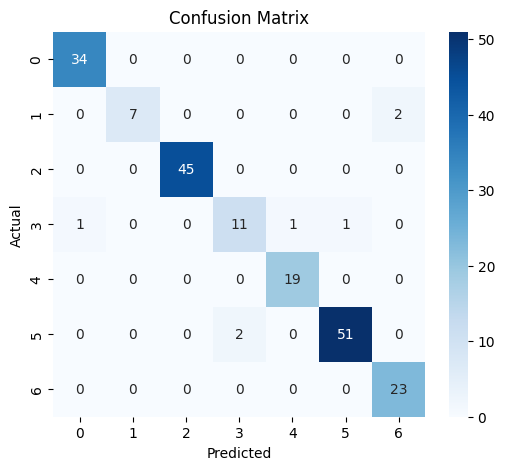

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib
torch.save(model.state_dict(), "emotion_model.pth")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selected_indices, "features.pkl")

['features.pkl']